<a href="https://colab.research.google.com/github/LucaSoames/EGH455/blob/main/models/YOLOv5_training_NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
while True:
    !nvidia-smi
    time.sleep(1)
    clear_output(wait=True)

# Install YOLOv5


In [1]:
# Set path to clone YOLOv5 repo
# %cd ./models
%ls

 Volume in drive C is Local Disk
 Volume Serial Number is 82A6-EE0C

 Directory of c:\Users\ncart\OneDrive\QUT\EGH455 Advanced Systems Design\EGH455\models\training

13/09/2025  10:12 AM    <DIR>          .
13/09/2025  09:56 AM    <DIR>          ..
11/09/2025  04:33 PM         9,266,547 Custom_Training_YoloV8.ipynb
13/09/2025  10:12 AM           151,282 dxdiag.txt
05/09/2025  09:13 AM         3,337,629 YOLOv5_training.ipynb
13/09/2025  09:53 AM           531,981 YOLOv8_training.ipynb
               4 File(s)     13,287,439 bytes
               2 Dir(s)  312,219,541,504 bytes free


In [3]:
# Clone YOLOv5 repository
!git clone https://github.com/ultralytics/yolov5 YOLOv5

fatal: destination path 'YOLOv5' already exists and is not an empty directory.


In [1]:
# install dependencies as necessary
!pip install -r YOLOv5/requirements.txt
!pip uninstall wandb -qy  # deprecated dependency
import torch
from IPython.display import Image, clear_output  # to display images

clear_output()
print("GPU detected = ", torch.cuda.is_available())  # Should print True
print(torch.cuda.get_device_name(0))  # Should show your GPU name
print('Setup complete. Using torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


: 

In [ ]:
# Change to YOLOv5 directory
%cd YOLOv5/
%ls

In [14]:
# Install Roboflow package
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Yg0BQvifINgpEz0Z2JI3")
project = rf.workspace("egh455-tblnn").project("egh455-jtll2-bvooc")
version = project.version(3)
clear_output()                
dataset = version.download("yolov5")

# Train Custom YOLOv5 Detector

### Next, we'll fire off training!


Here, we are able to pass a number of arguments:
- **img:** define input image size
- **batch:** determine batch size
- **epochs:** define the number of training epochs. (Note: often, 3000+ are common here!)
- **data:** set the path to our yaml file
- **cfg:** specify our model configuration
- **weights:** specify a custom path to weights. (Note: you can download weights from the Ultralytics Google Drive [folder](https://drive.google.com/open?id=1Drs_Aiu7xx6S-ix95f9kNsA6ueKRpN2J))
- **name:** result names
- **cache:** cache images for faster training

In [ ]:
# Make sure we are in the YOLOv5 directory
# %cd ./YOLOv5/
%ls

In [15]:

print(f"Dataset location: {dataset.location}")
yaml_path = dataset.location + "\data.yaml"
print(f"YAML path: {yaml_path}")

Dataset location: c:\Users\ncart\OneDrive\QUT\EGH455 Advanced Systems Design\EGH455\models\YOLOv5\EGH455-3
YAML path: c:\Users\ncart\OneDrive\QUT\EGH455 Advanced Systems Design\EGH455\models\YOLOv5\EGH455-3\data.yaml


In [ ]:
# TRAIN YOLOv5s on custom data for X epochs
%time # time its performance

# !python train.py --img 640 --batch 16 --epochs 300 --data "{yaml_path}" --weights yolov5s.pt --name yolov5s_results --cache disk --workers 4
!python train.py --img 640 --batch 24 --epochs 300 --data "c:\Users\ncart\OneDrive\QUT\EGH455 Advanced Systems Design\EGH455\models\YOLOv5\EGH455-3\data.yaml" --weights yolov5s.pt --name yolov5s_results --cache disk --workers 4 --device 0
# Add --resume to resume training from last epoch

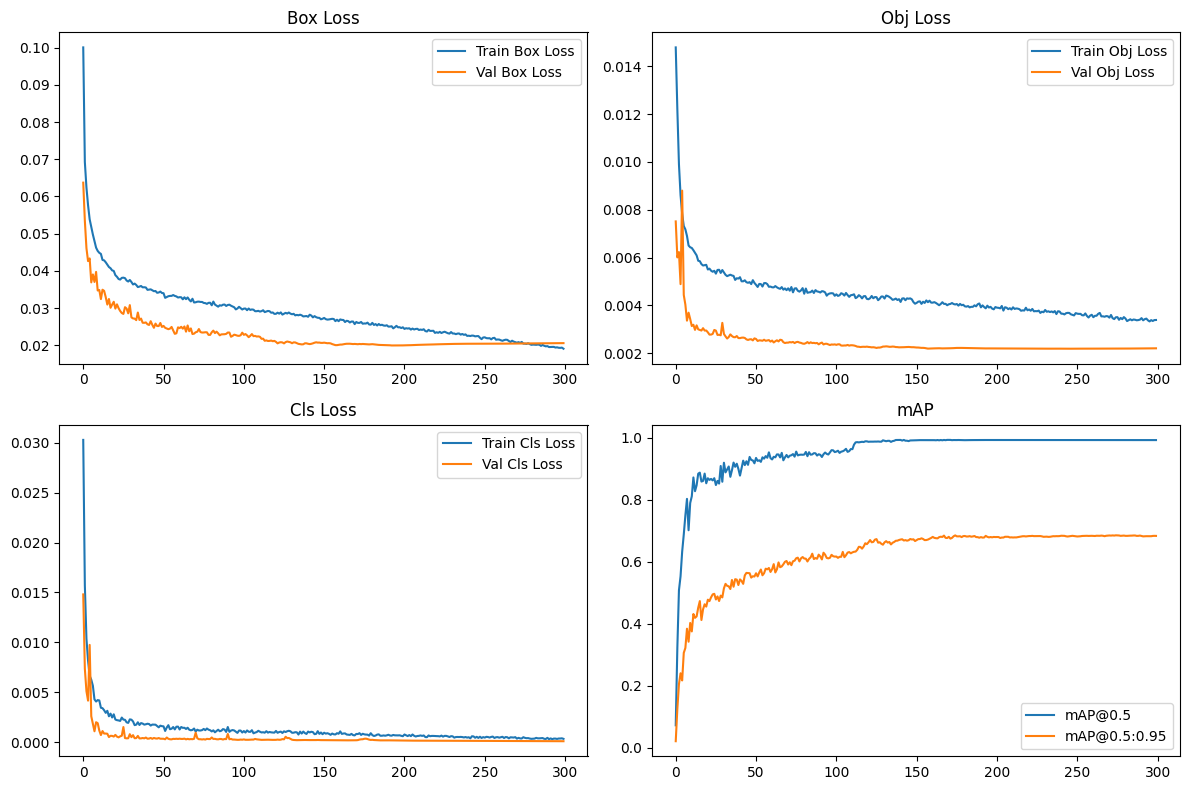

In [5]:
# Visualise training plots
import pandas as pd
import matplotlib.pyplot as plt

# Load results.csv (adjust path if needed)
results_path = 'runs/train/yolov5s_results/results.csv'
df = pd.read_csv(results_path)

# Strip leading spaces from column names
df.columns = df.columns.str.strip()

# Plot key metrics (e.g., mAP, loss)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.legend()
plt.title('Box Loss')

plt.subplot(2, 2, 2)
plt.plot(df['epoch'], df['train/obj_loss'], label='Train Obj Loss')
plt.plot(df['epoch'], df['val/obj_loss'], label='Val Obj Loss')
plt.legend()
plt.title('Obj Loss')

plt.subplot(2, 2, 3)
plt.plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss')
plt.plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss')
plt.legend()
plt.title('Cls Loss')

plt.subplot(2, 2, 4)
plt.plot(df['epoch'], df['metrics/mAP_0.5'], label='mAP@0.5')
plt.plot(df['epoch'], df['metrics/mAP_0.5:0.95'], label='mAP@0.5:0.95')
plt.legend()
plt.title('mAP')

plt.tight_layout()
plt.show()

# Evaluate Custom YOLOv5 Detector Performance

You can view the training graphs associated with a training job in the `/content/yolov5/runs/train/yolov5s_results/results.png` folder.

Training losses and performance metrics are also saved to Tensorboard and also to a logfile defined above with the **--name** flag when we train. In our case, we named this `yolov5s_results`.

Note from Glenn: Partially completed `results.txt` files can be plotted with `from utils.utils import plot_results; plot_results()`.

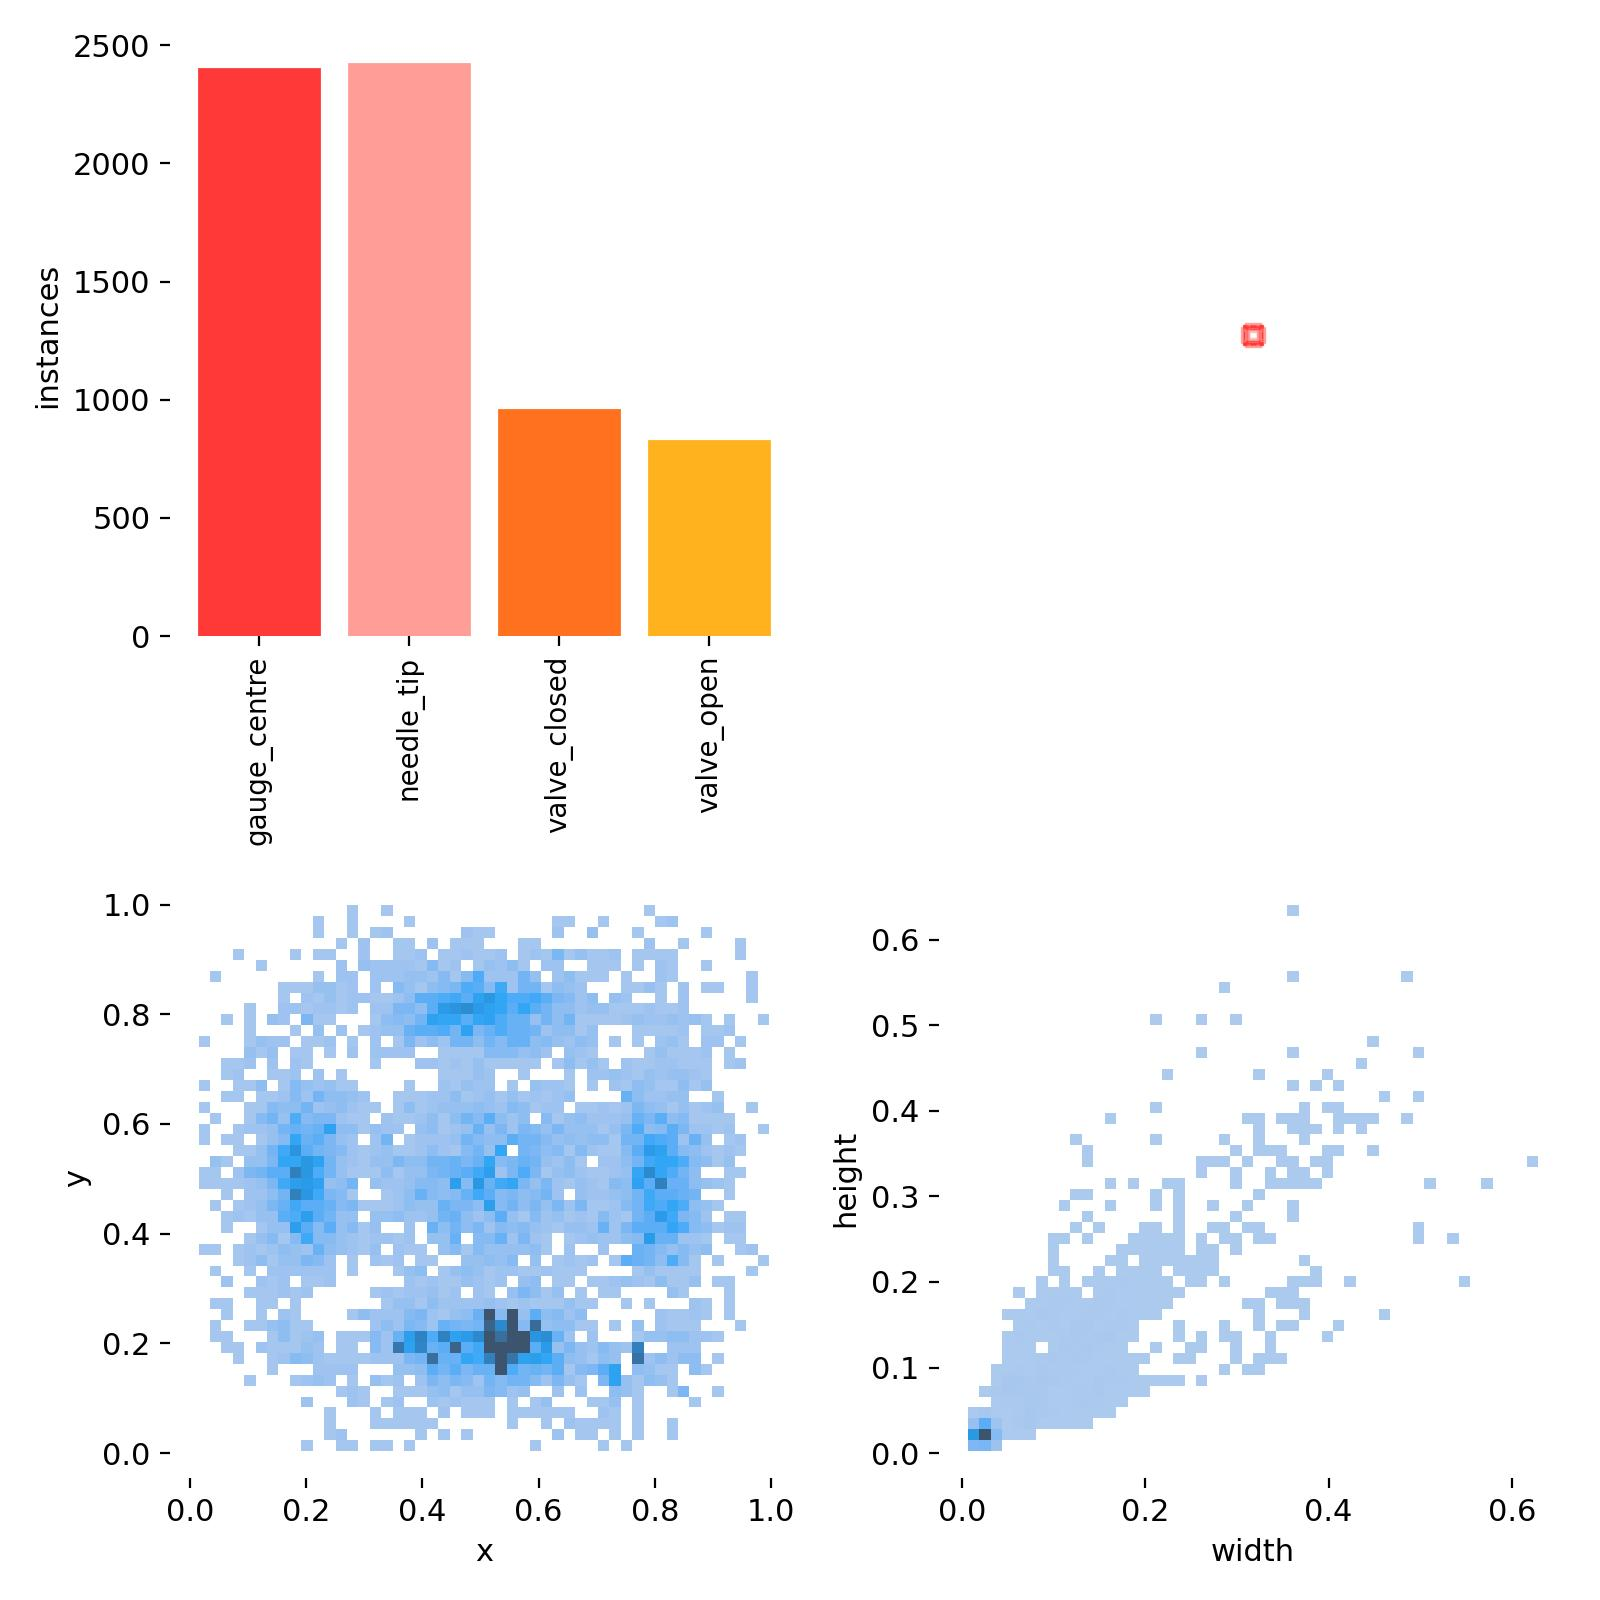

In [ ]:
from utils.plots import plot_results  # plot results.txt as results.png
Image(filename="runs/train/yolov5s_results/labels.jpg", width=1000)


### Curious? Visualize Our Training Data with Labels

After training starts, view `train*.jpg` images to see training images, labels and augmentation effects.

Note a mosaic dataloader is used for training (shown below), a new dataloading concept developed by Glenn Jocher and first featured in [YOLOv4](https://arxiv.org/abs/2004.10934).

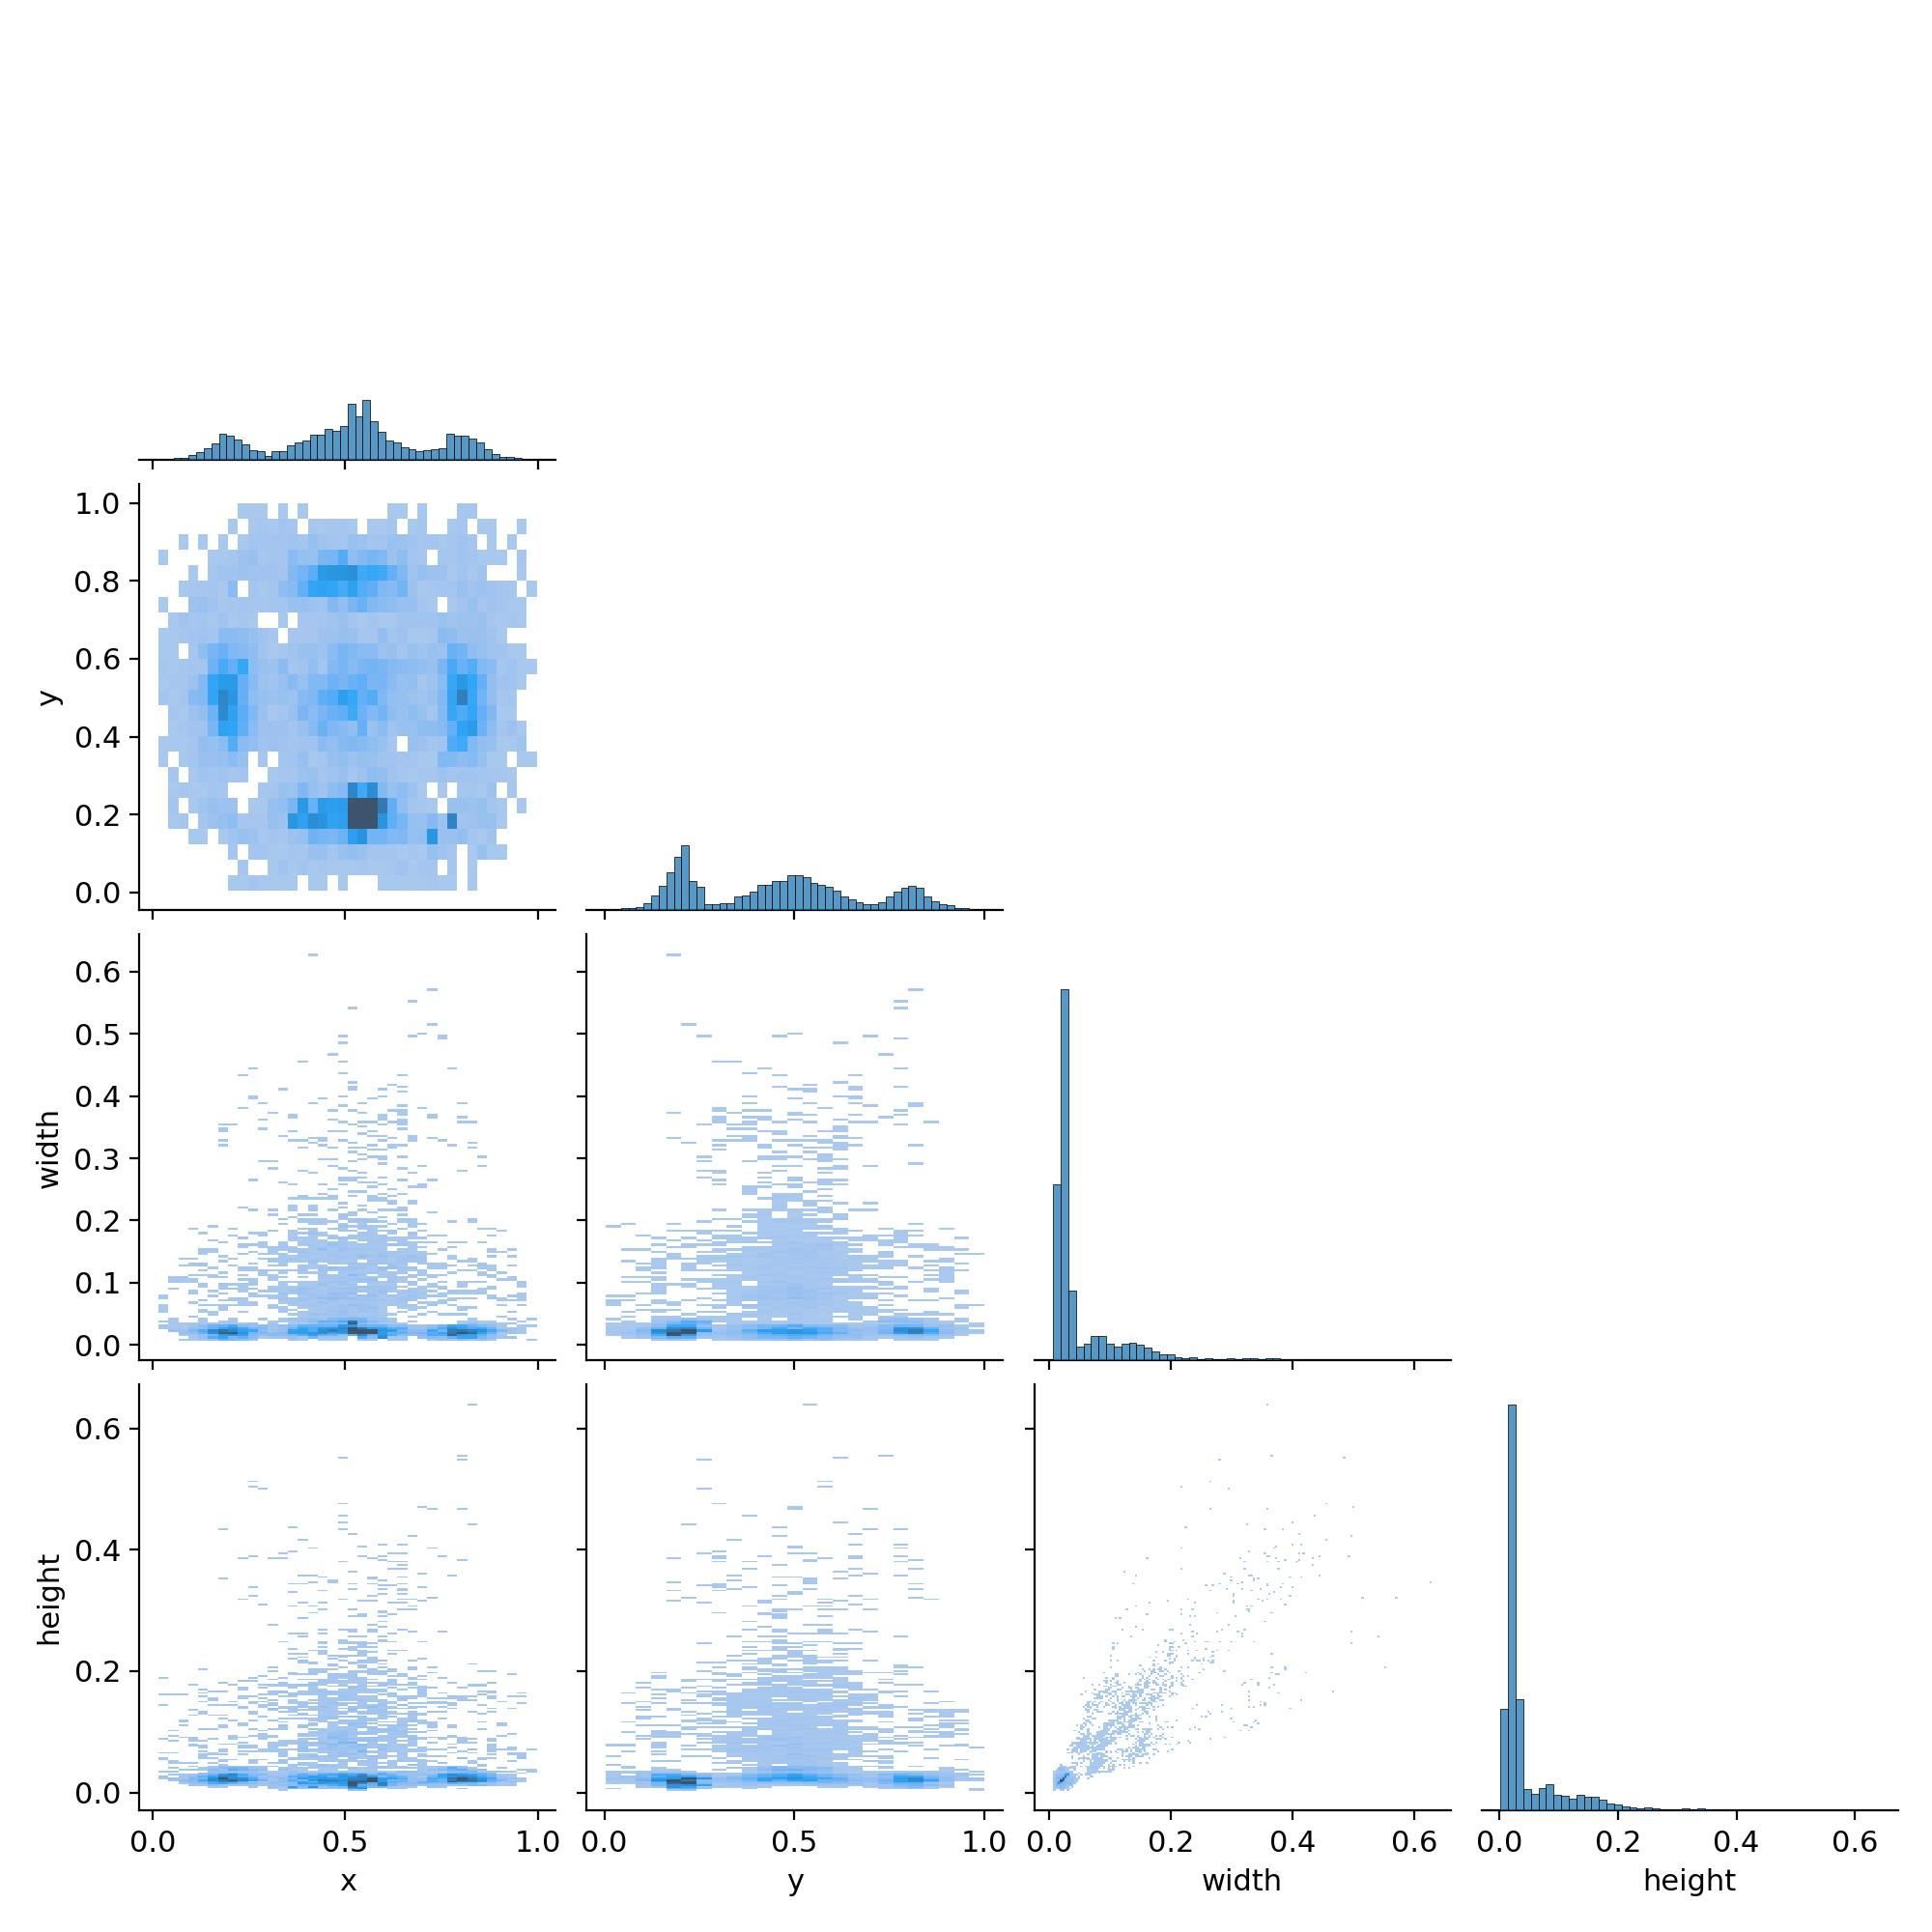

In [8]:
Image(filename="runs/train/yolov5s_results/labels_correlogram.jpg", width=900)

GROUND TRUTH AUGMENTED TRAINING DATA:


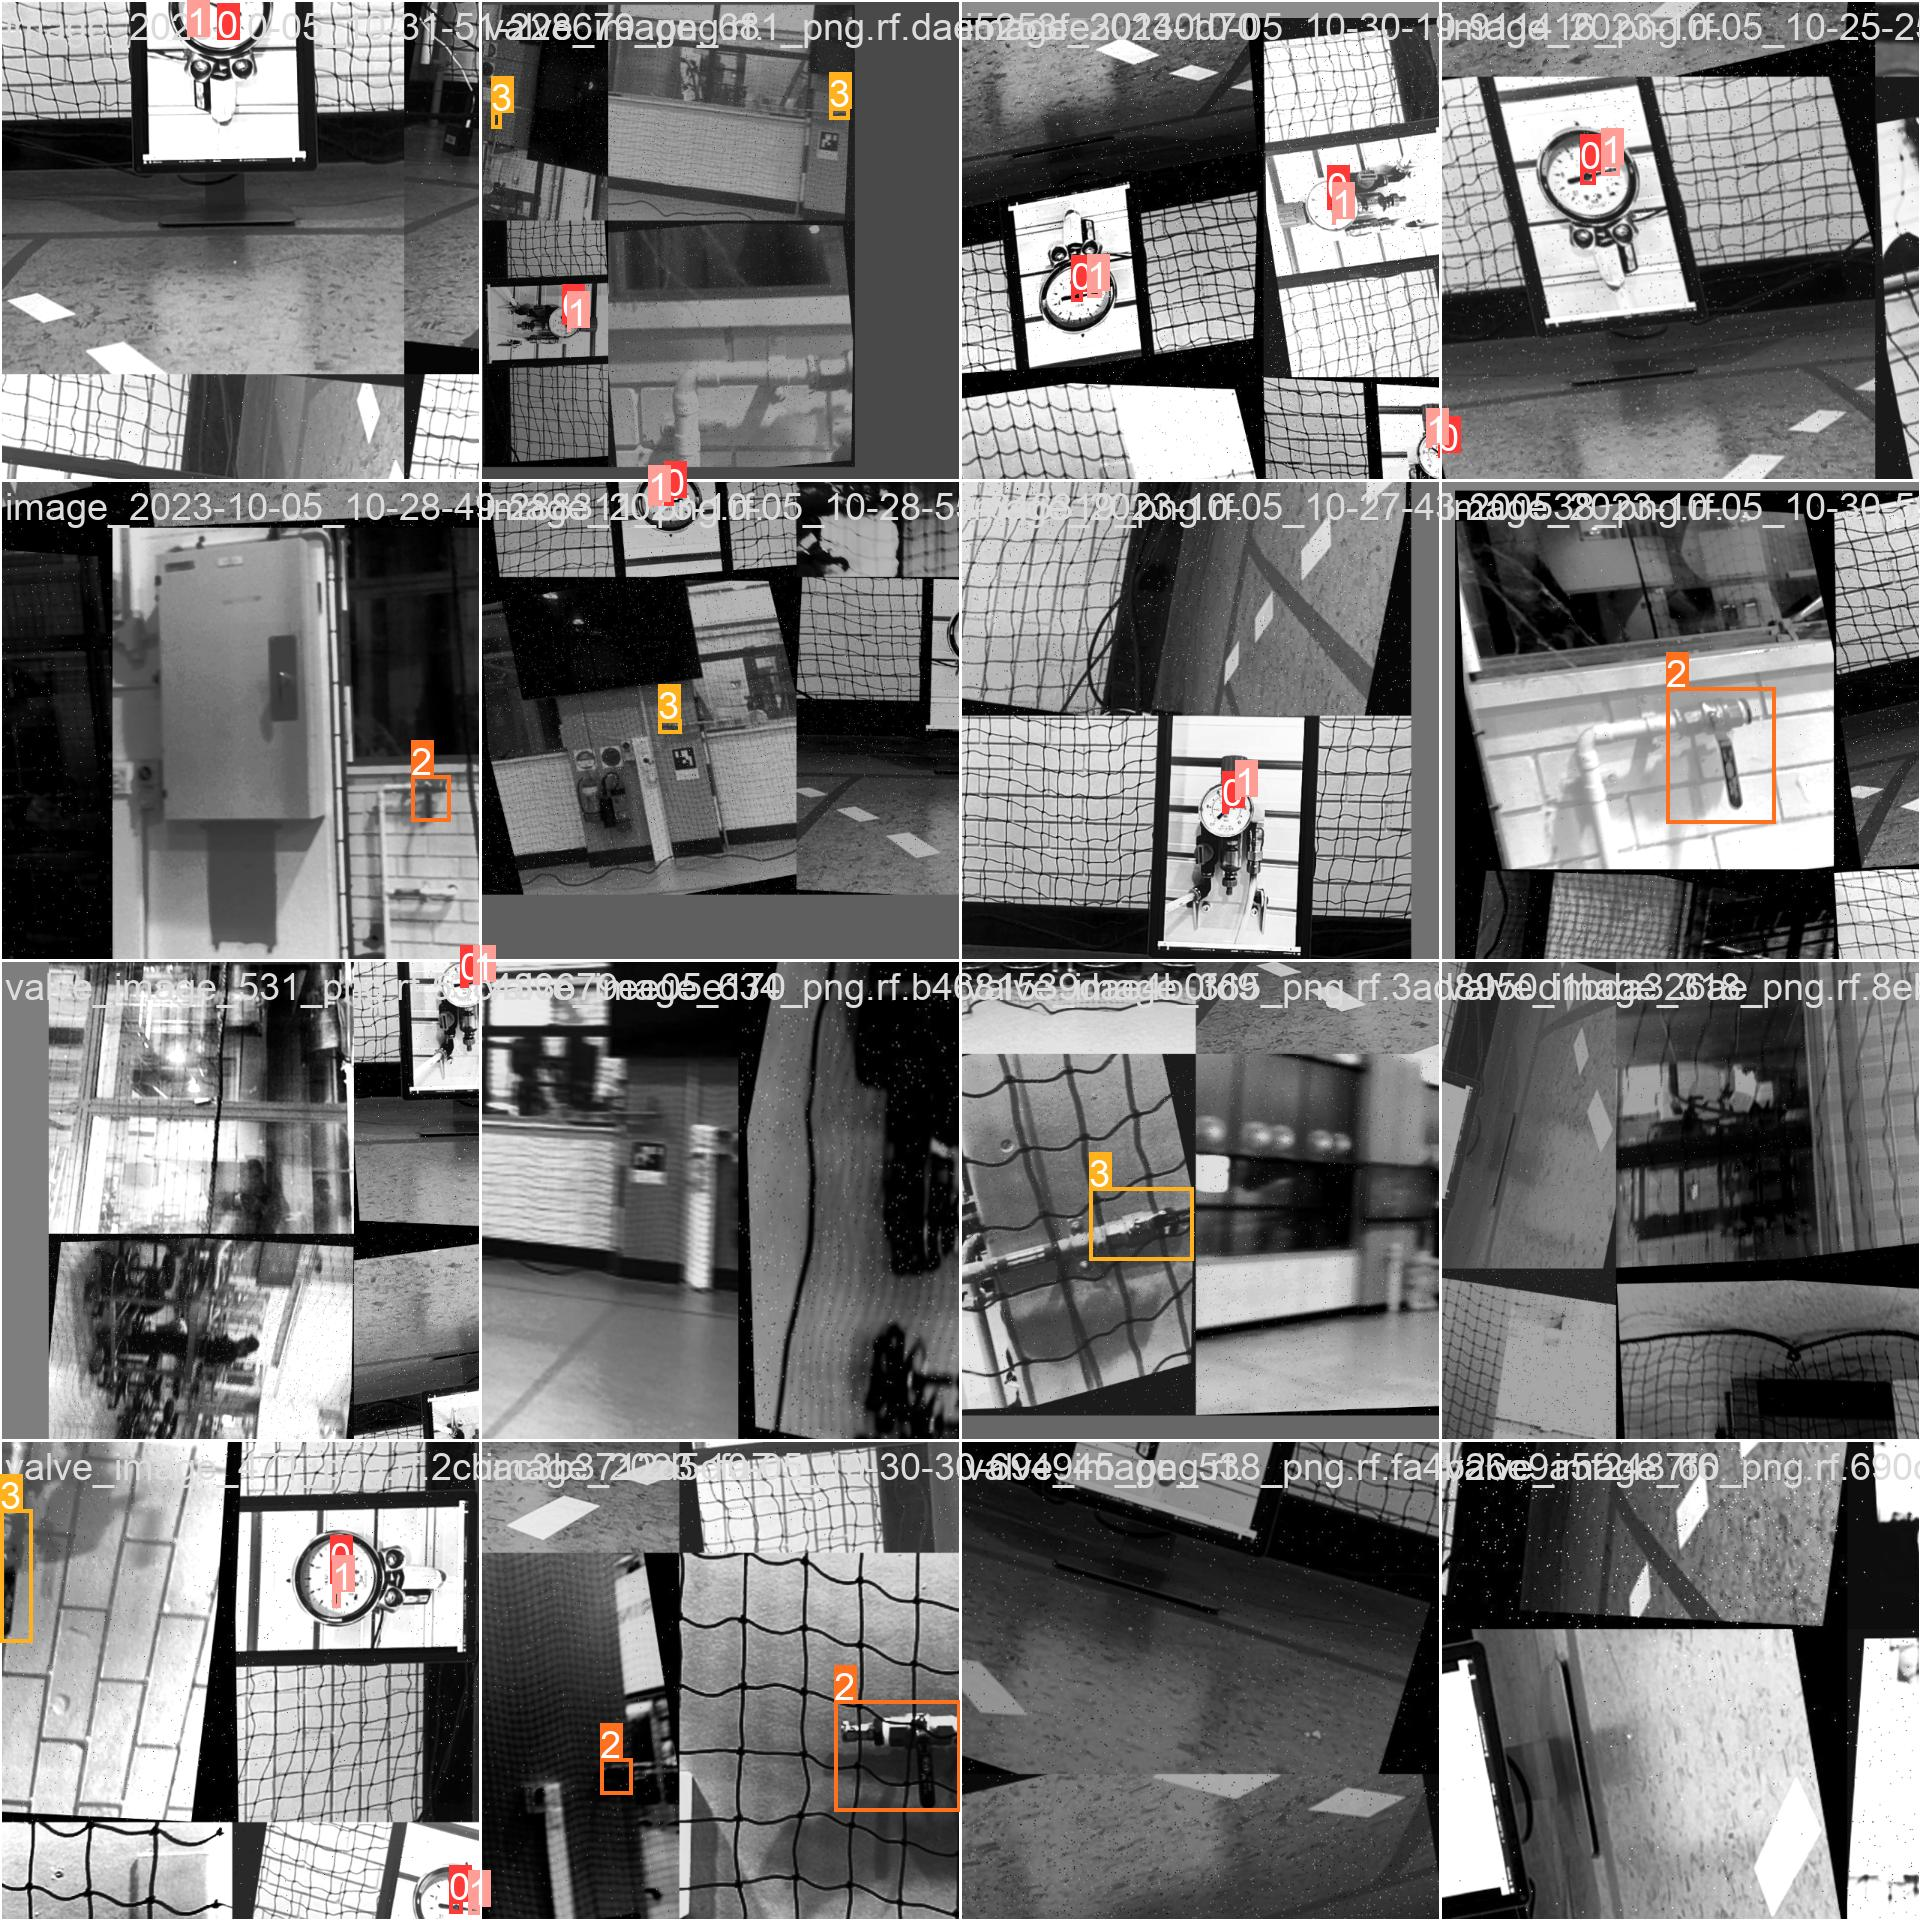

In [ ]:
# print out an augmented training example
print("GROUND TRUTH AUGMENTED TRAINING DATA:")
Image(filename='runs/train/yolov5s_results/train_batch0.jpg', width=900)

# Run Inference With Trained Weights

Next, we can run inference with a pretrained checkpoint on all images in the `test/images` folder to understand how our model performs on our test set.

In [25]:
best_weights = "c:\Users\ncart\OneDrive\QUT\EGH455 Advanced Systems Design\EGH455\models\YOLOv5\runs\train\yolov5s_results\weights\best.pt"
test_images = "c:\Users\ncart\OneDrive\QUT\EGH455 Advanced Systems Design\EGH455\models\YOLOv5\EGH455-3\test\images"

!python detect.py --weights "c:\Users\ncart\OneDrive\QUT\EGH455 Advanced Systems Design\EGH455\models\YOLOv5\runs\train\yolov5s_results\weights\best.pt" --img 640 --conf 0.35 --source "c:\Users\ncart\OneDrive\QUT\EGH455 Advanced Systems Design\EGH455\models\YOLOv5\EGH455-3\test\images"

# REUSLTS:
# Speed: 1.0ms pre-process, 14.0ms inference, 5.5ms NMS per image at shape (1, 3, 640, 640)
# Results saved to runs\detect\exp2

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (4134447199.py, line 1)

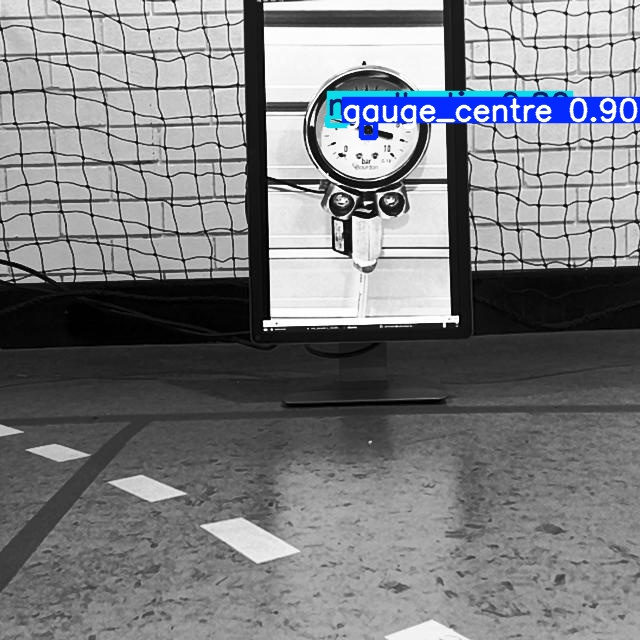

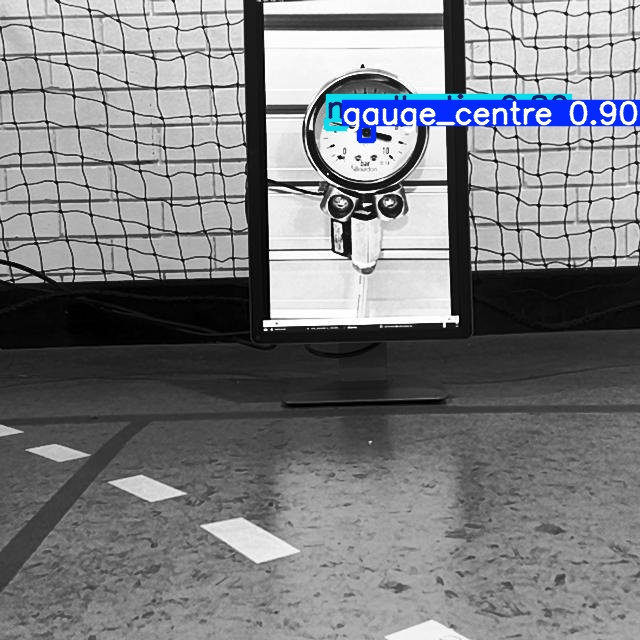

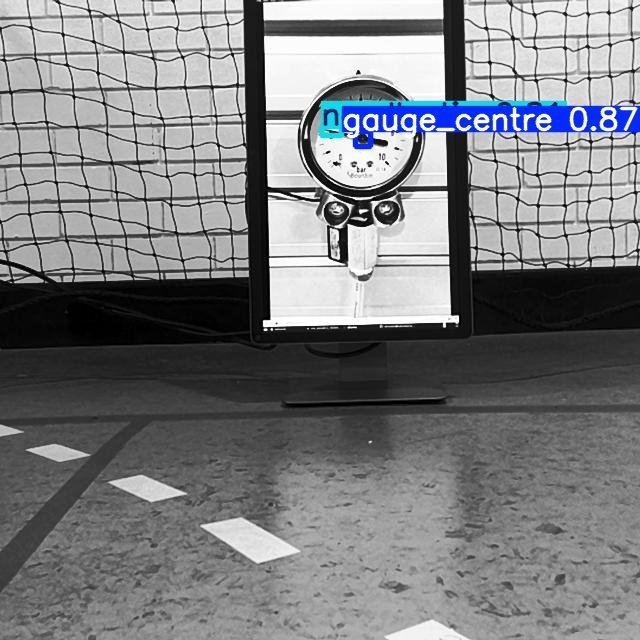

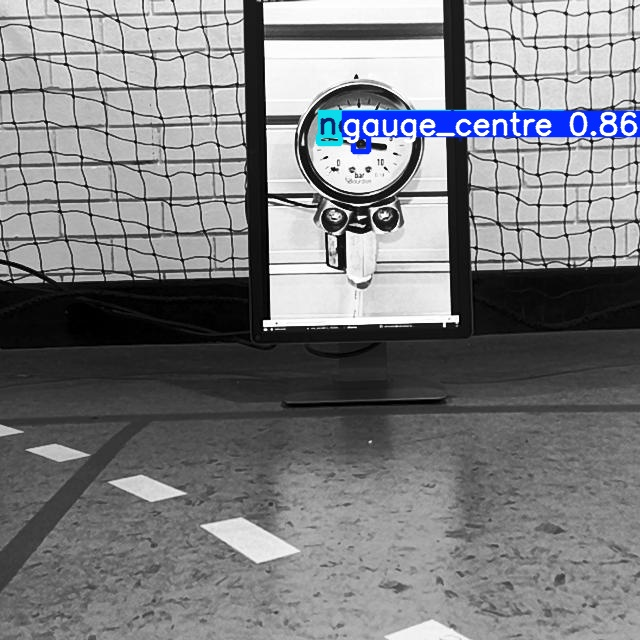

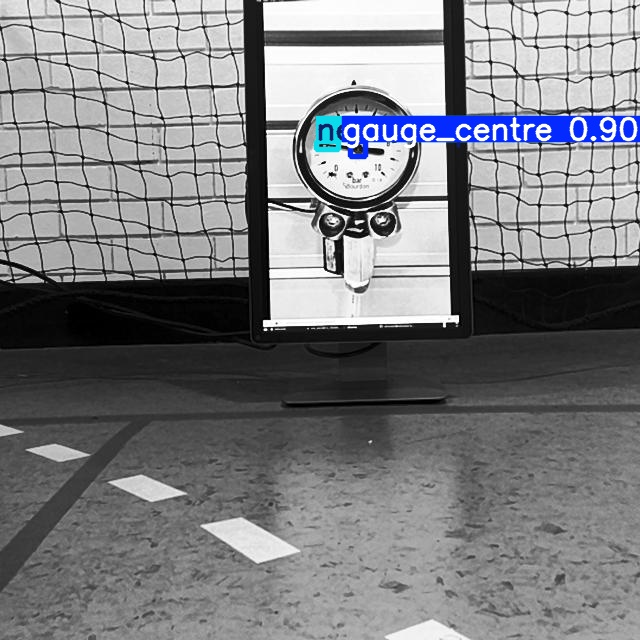

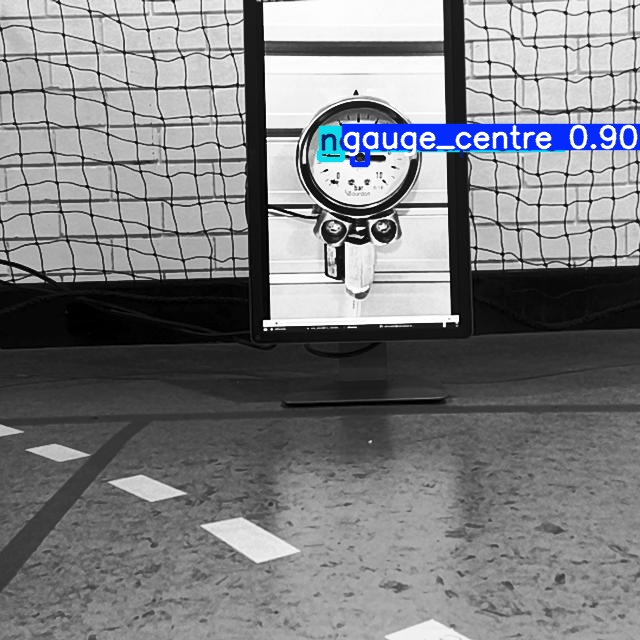

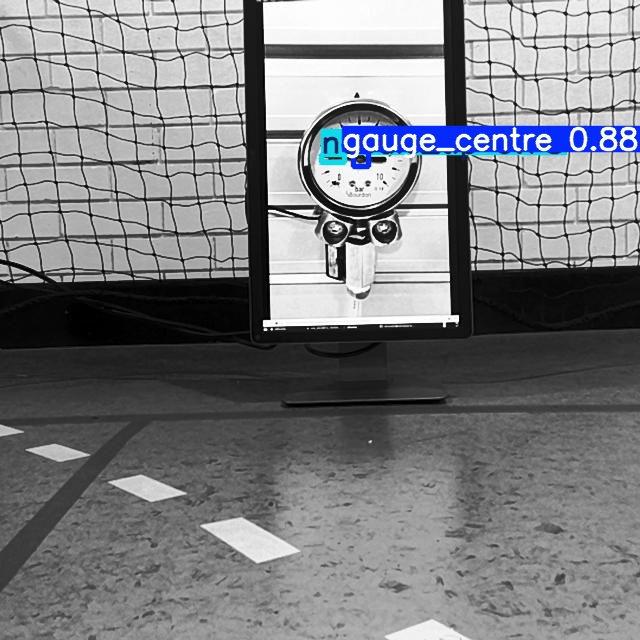

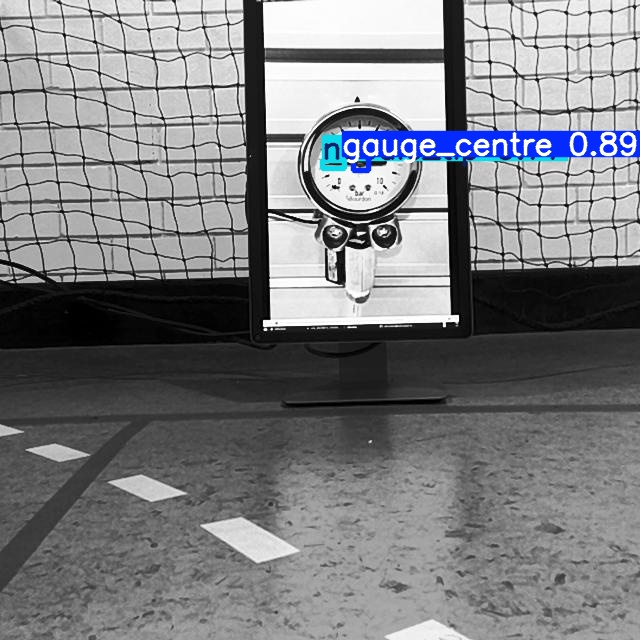

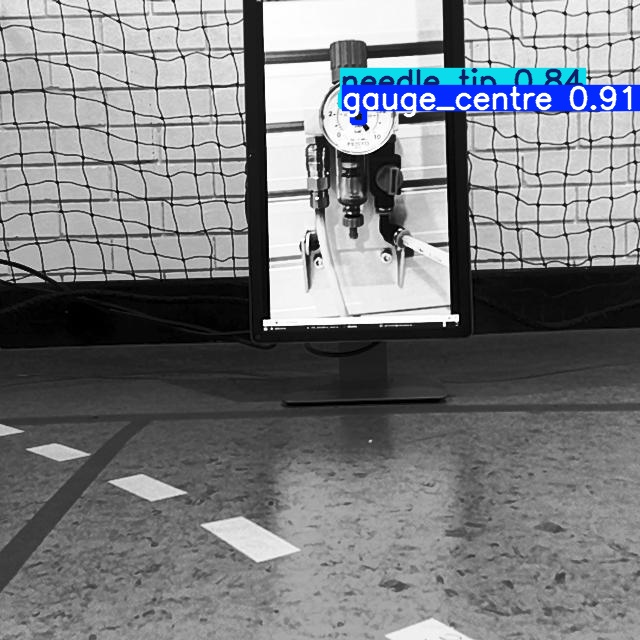

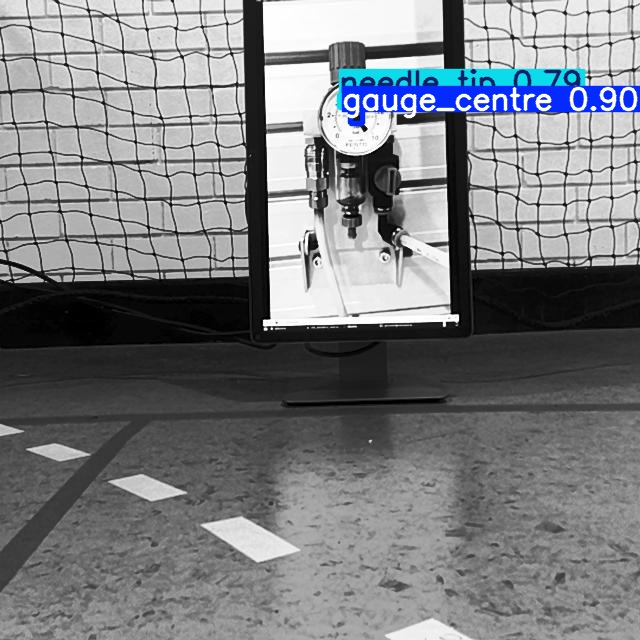

In [27]:
import glob
from IPython.display import Image, display

for imageName in glob.glob('runs/detect/exp/*.jpg')[:10]: #assuming JPG
    display(Image(filename=imageName))

## Deploy Model on Roboflow

Once you have finished training your YOLOv5 model, you’ll have a set of trained weights ready for use. These weights will be in the `/content/yolov5/runs/train/yolov5s_results/` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv5 weights.

**Before you run this code, make sure you create a new Version in the Roboflow dashboard following the instructions we covered earlier. Fill in your project name, workspace, and version number below.**

To upload model weights, add the following code to the “Inference with Custom Model” section in the aforementioned notebook:

In [ ]:
project.version(dataset.version).deploy(model_type="yolov5", model_path=f"/content/yolov5/runs/train/yolov5s_results/")

In [ ]:
#Run inference on your model on a persistant, auto-scaling, cloud API

#load model
model = project.version(dataset.version).model

#choose random test set image
import os, random
test_set_loc = dataset.location + "/test/images/"
random_test_image = random.choice(os.listdir(test_set_loc))
print("running inference on " + random_test_image)

pred = model.predict(test_set_loc + random_test_image, confidence=40, overlap=30).json()
pred

# Deploy Your Model to the Edge

In addition to using the Roboflow hosted API for deployment, you can use [Roboflow Inference](https://inference.roboflow.com), an open source inference solution that has powered millions of API calls in production environments. Inference works with CPU and GPU, giving you immediate access to a range of devices, from the NVIDIA Jetson to TRT-compatible devices to ARM CPU devices.

With Roboflow Inference, you can self-host and deploy your model on-device. You can deploy applications using the [Inference Docker containers](https://inference.roboflow.com/quickstart/docker/) or the pip package.

For example, to install Inference on a device with an NVIDIA GPU, we can use:
